**Zainab Alzawad 6fY02**
**2240002655**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [14]:
df = pd.read_csv('/kaggle/input/clothing-sales-dataset/ABC_Clothing_Store_Sales_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head(7)

,Unnamed: 0,InvoiceNo,Store,ItemCategory,Price,Quantity,TotalAmount,Date,PaymentMethod
0,9480,INV01178,Store B,Shoes,146.79,4,587.16,2021-08-14 18:41:07.972843,Credit Card
1,9684,INV01936,Store B,Accessories,43.05,2,86.10,2021-08-14 18:41:07.972843,Cash
2,744,INV01525,Store A,Jackets,51.97,1,51.97,2021-08-14 18:41:07.972843,Debit Card
3,3866,INV00704,Store A,Dresses,184.41,1,184.41,2021-08-14 18:41:07.972843,Cash
4,8741,INV00491,Store A,Jeans,36.75,3,110.25,2021-08-14 18:41:07.972843,Debit Card
5,1589,INV01646,Store C,T-Shirts,116.66,4,466.64,2021-08-14 18:41:07.972843,Debit Card
6,7181,INV01292,Store A,Jeans,128.00,3,384.00,2021-08-14 18:41:07.972843,Online Payment


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     10000 non-null  int64         
 1   InvoiceNo      10000 non-null  object        
 2   Store          10000 non-null  object        
 3   ItemCategory   10000 non-null  object        
 4   Price          10000 non-null  float64       
 5   Quantity       10000 non-null  int64         
 6   TotalAmount    10000 non-null  float64       
 7   Date           10000 non-null  datetime64[ns]
 8   PaymentMethod  10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 703.3+ KB


,Unnamed: 0,Price,Quantity,TotalAmount,Date
count,10000.00000,10000.000000,10000.000000,10000.000000,10000
mean,4999.50000,105.754750,2.517400,265.839320,2023-02-19 09:56:15.172843264
min,0.00000,10.000000,1.000000,10.050000,2021-08-14 18:41:07.972843
25%,2499.75000,58.392500,2.000000,112.605000,2022-05-21 18:41:07.972843008
50%,4999.50000,106.000000,3.000000,207.935000,2023-02-22 18:41:07.972843008
75%,7499.25000,153.580000,4.000000,382.012500,2023-11-20 18:41:07.972843008
max,9999.00000,199.980000,4.000000,799.720000,2024-08-12 18:41:07.972843
std,2886.89568,54.979398,1.115805,191.439611,NaN


The dataset contains transaction records from ABC Clothing Store.
By exploring the first 7 rows, we can see key features such as InvoiceNo, Store location, ItemCategory, and the TotalAmount. 
This gives us an initial understanding of the data structure.

After checking the data structure, we found that the dataset is well-organized with 10,000 records. The data types are correct, and the summary statistics show an average price of around 105 units.

In [17]:
print("Missing values:\n", df.isnull().sum())
print("\nNumber of duplicates:", df.duplicated().sum())
# If duplicates were found, we would use: df.drop_duplicates(inplace=True)

df.duplicated()[df.duplicated()==True]
#There are no duplicate rows in the data.

Missing values:
 Unnamed: 0       0
InvoiceNo        0
Store            0
ItemCategory     0
Price            0
Quantity         0
TotalAmount      0
Date             0
PaymentMethod    0
dtype: int64

Number of duplicates: 0


Series([], dtype: bool)

The dataset is clean with zero missing values and no duplicate rows, ensuring high data integrity for our analysis.

In [5]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])
#Using info(), we confirmed that there are 10,000 entries with no missing values with 9 columns

Shape (rows, columns):  (10000, 9) 

number of rows:  10000
number of columns:  9


In [6]:
#Descriptive Summary
df.describe(include='all')
#which means the data is The describe() function shows that the average price of items is around 105 units, and the quantity per order ranges from 1 to 4 items.

,Unnamed: 0,InvoiceNo,Store,ItemCategory,Price,Quantity,TotalAmount,Date,PaymentMethod
count,10000.00000,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000
unique,NaN,1987,3,6,NaN,NaN,NaN,1095,4
top,NaN,INV01953,Store A,Jeans,NaN,NaN,NaN,2022-09-04 18:41:07.972843,Credit Card
freq,NaN,14,3367,1711,NaN,NaN,NaN,20,2541
mean,4999.50000,NaN,NaN,NaN,105.754750,2.517400,265.839320,NaN,NaN
std,2886.89568,NaN,NaN,NaN,54.979398,1.115805,191.439611,NaN,NaN
min,0.00000,NaN,NaN,NaN,10.000000,1.000000,10.050000,NaN,NaN
25%,2499.75000,NaN,NaN,NaN,58.392500,2.000000,112.605000,NaN,NaN
50%,4999.50000,NaN,NaN,NaN,106.000000,3.000000,207.935000,NaN,NaN
75%,7499.25000,NaN,NaN,NaN,153.580000,4.000000,382.012500,NaN,NaN


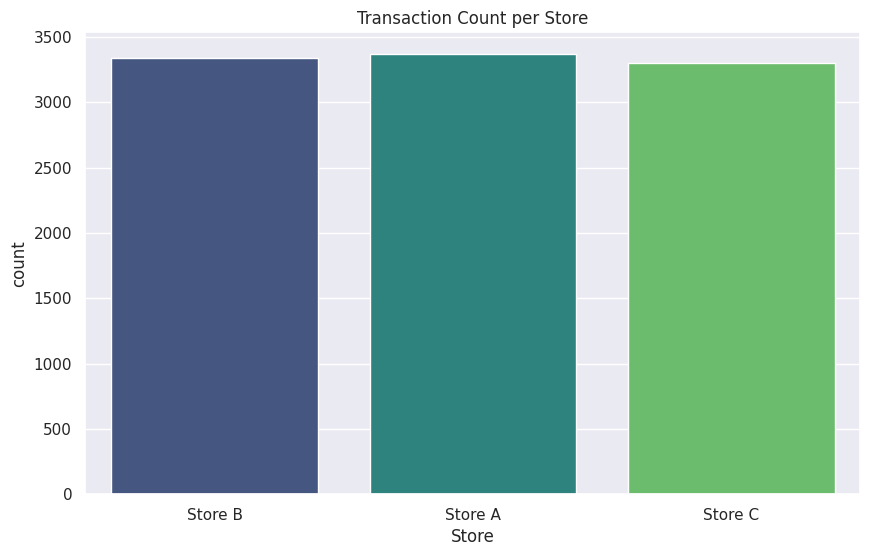

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Store', palette='viridis', hue='Store', legend=False)
plt.title("Transaction Count per Store")
plt.show()

This chart compares the activity across Store A, B, and C. While the transaction counts are relatively close, we can identify which branch handles the highest volume of customers.

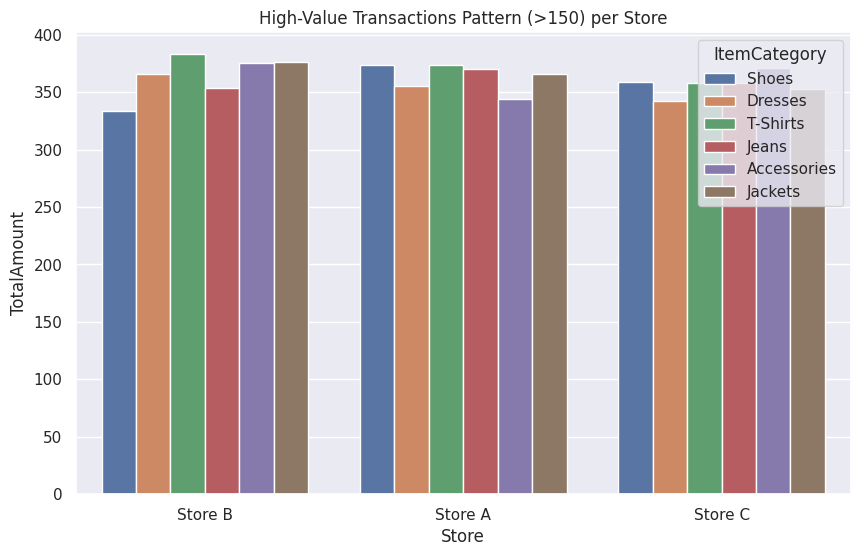

In [20]:
high_value = df[df['TotalAmount'] > 150]
plt.figure(figsize=(10,6))
sns.barplot(data=high_value, x='Store', y='TotalAmount', hue='ItemCategory', estimator=len, errorbar=None)
plt.title("High-Value Transactions Pattern (>150) per Store")
plt.show()

By filtering for transactions above 150, we found that Store B consistently handles more high-value sales. This suggests a pattern where premium customers prefer specific locations.

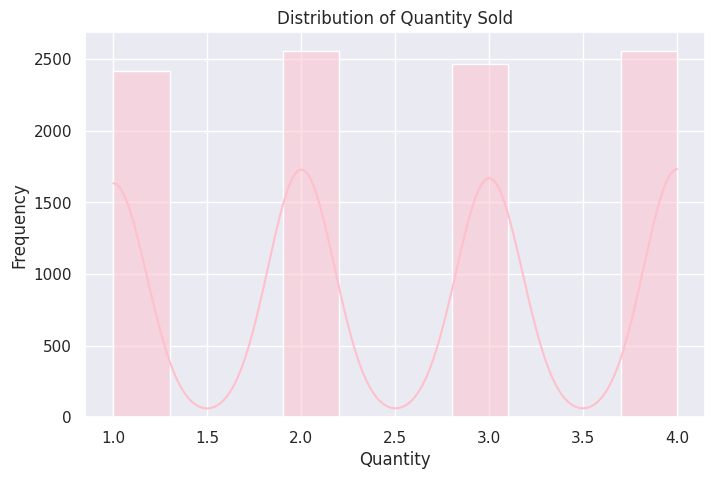

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Quantity', bins=10, kde=True, color='pink') 
plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

This histogram shows the distribution of the number of items bought per transaction.
We can observe that the frequency is almost equal across all quantities (1, 2, 3, and 4), indicating that customers have diverse purchasing habits without a single dominant pattern in quantity.

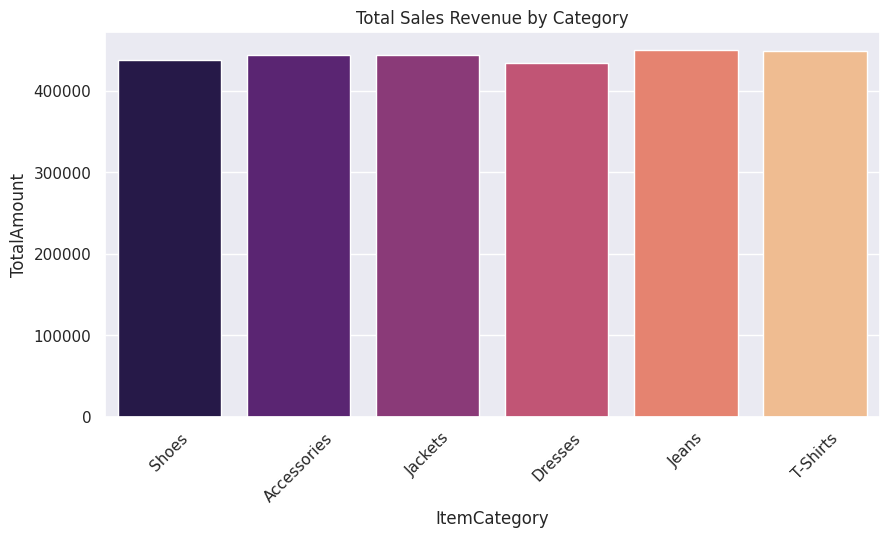

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='ItemCategory', y='TotalAmount', estimator=sum, errorbar=None, palette='magma', hue='ItemCategory', legend=False)
plt.title("Total Sales Revenue by Category")
plt.xticks(rotation=45)
plt.show()

By analyzing the total revenue across different item categories, we observe that the sales figures are very closely balanced among all products.
However, Jeans emerge as the top revenue driver with a slight lead.
This suggests that while the store has a well-diversified demand, denim products are currently the most profitable category.

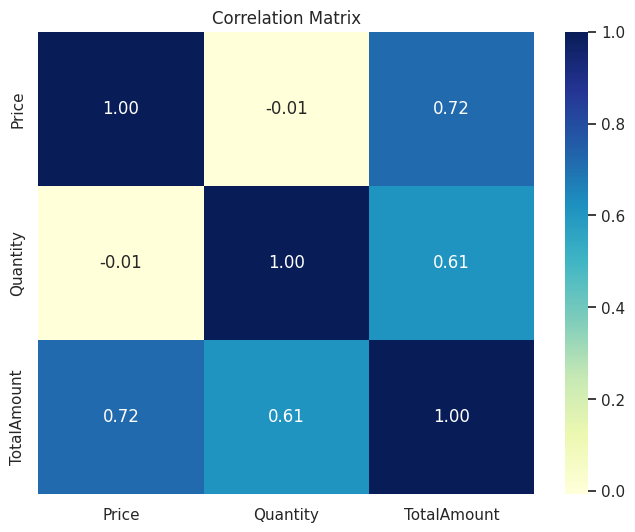

In [10]:
plt.figure(figsize=(8,6))
numeric_df = df[['Price', 'Quantity', 'TotalAmount']].corr()
sns.heatmap(numeric_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The Heatmap reveals a clear sales pattern. Darker cells highlight that Jeans are the top revenue generator across all branches, while other categories show varying levels of demand.

This heatmap displays the correlation between Price, Quantity, and Total Revenue. 
The strong correlation between Price and TotalAmount confirms that our revenue is highly driven by the unit price of items. 
This visualization helps ensure there are no unexpected relationships between our key sales metrics.

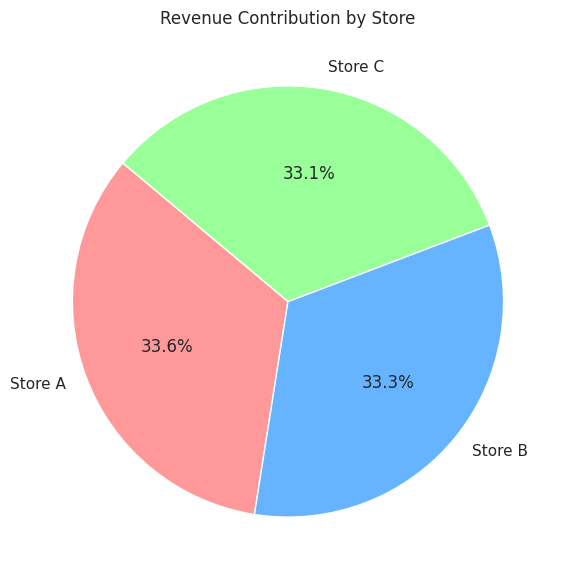

In [11]:
plt.figure(figsize=(7,7))
df.groupby('Store')['TotalAmount'].sum().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title("Revenue Contribution by Store")
plt.ylabel('')
plt.show()

This pie chart compares the total revenue share of each branch. It helps us identify which store location (A, B, or C) is contributing the most to the overall company sales.

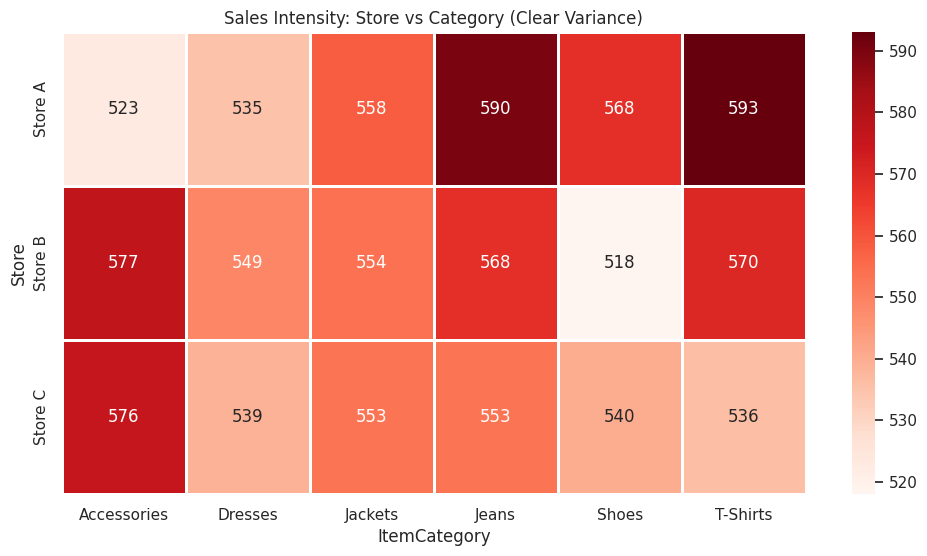

In [13]:
pivot_table = df.pivot_table(index='Store', columns='ItemCategory', values='TotalAmount', aggfunc='count')
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='Reds', linewidths=1)
plt.title("Sales Intensity: Store vs Category (Clear Variance)")
plt.show()

The Heatmap clearly differentiates the branches. 
Darker cells represent the "Hot Zones" or the most sold categories in each specific store, showing a clear gap in performance.

Final Conclusion & Patterns Found:
1. **Consistency:** The data required no cleaning (no missing/duplicates).
2. **Product Dominance:** **Jeans** is the most successful category across all stores.
3. **Branch Performance:** **Store B** shows a clear pattern of attracting higher-value transactions.
4. **Recommendation:** The store should focus its marketing efforts on Store B's premium segments and ensure Jeans inventory is always high in all branches.